## TP de Régression (Machine Learning)
**Nom Complet :** Mohammed NASSIRI

**Utilisateur GitHub :** PunchArm255

**Date :** 9 Avril 2026

---

### IMPORTATION DES BIBLIOTHÈQUES

In [ ]:
# Pandas est utilisé pour charger et manipuler notre jeu de données (fichiers CSV)
import pandas as pd
# Numpy est le moteur mathématique, utilisé ici pour l'algèbre linéaire (matrices)
import numpy as np
# Matplotlib permet de tracer les graphiques et de visualiser nos résultats
import matplotlib.pyplot as plt
# Scikit-Learn fournit les implémentations professionnelles pour comparer nos calculs
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Commande magique Jupyter pour forcer l'affichage des graphiques directement sous les cellules
%matplotlib inline

### IMPLÉMENTATION DE L'ÉQUATION NORMALE

In [ ]:
class RegressionFromScratch:
    def __init__(self):
        # theta contiendra nos poids optimaux (l'ordonnée à l'origine et les pentes)
        self.theta = None

    def fit(self, X_train, y_train):
        # ÉTAPE 1 : Ajouter une colonne de 1 à la matrice X
        # Cela permet de calculer le biais (beta_0 ou l'ordonnée à l'origine)
        X_b = np.c_[np.ones((len(X_train), 1)), X_train]
        
        # ÉTAPE 2 : Appliquer l'Équation Normale
        # Formule mathématique : theta = (X^T * X)^-1 * X^T * y
        # - .T effectue la transposée de la matrice
        # - .dot() effectue la multiplication matricielle
        # - np.linalg.inv() calcule l'inverse de la matrice
        self.theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_train)

    def predict(self, X_test):
        # Pour prédire de nouvelles valeurs, on ajoute aussi la colonne de 1
        X_b = np.c_[np.ones((len(X_test), 1)), X_test]
        # On multiplie les nouvelles données par les poids calculés
        return X_b.dot(self.theta)

### PRÉPARATION DES DONNÉES

In [ ]:
# Chargement du fichier CSV généré contenant les coûts médicaux
df = pd.read_csv('data/medical_costs.csv')

# Extraction des variables pour la régression linéaire simple (1 variable explicative)
# X_simple = Âge du patient | y = Coût médical associé
X_simple = df[['age']].values
y = df[['cost']].values

# Extraction des variables pour la régression multiple (3 variables explicatives)
# X_multi = Âge, Indice de Masse Corporelle (BMI), et Nombre d'enfants
X_multi = df[['age', 'bmi', 'children']].values

### TEST 1 : RÉGRESSION LINÉAIRE SIMPLE

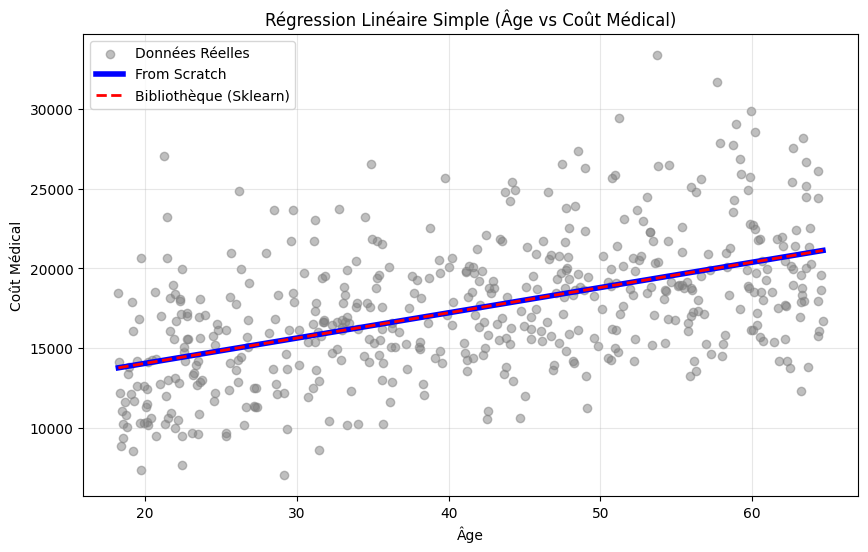

In [ ]:
# ==========================================
# Objectif : Prédire le coût uniquement à partir de l'âge
# ==========================================

# 1. Entraînement de notre modèle manuel
model_simple = RegressionFromScratch()
model_simple.fit(X_simple, y)

# 2. Entraînement du modèle de la bibliothèque (Scikit-Learn) pour vérification
sk_simple = LinearRegression().fit(X_simple, y)

# 3. Création d'une ligne continue pour tracer nos prédictions proprement
X_plot = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)

# 4. Visualisation
plt.figure(figsize=(10, 6))
# Affichage des vraies données en gris
plt.scatter(X_simple, y, color='gray', alpha=0.5, label='Données Réelles')
# Affichage de notre droite mathématique (Épaisse et bleue)
plt.plot(X_plot, model_simple.predict(X_plot), color='blue', linewidth=4, label='From Scratch')
# Affichage de la droite de Scikit-Learn (Pointillée et rouge, superposée à la nôtre)
plt.plot(X_plot, sk_simple.predict(X_plot), color='red', linestyle='dashed', linewidth=2, label='Bibliothèque (Sklearn)')

# Formatage du graphique
plt.title('Régression Linéaire Simple (Âge vs Coût Médical)')
plt.xlabel('Âge')
plt.ylabel('Coût Médical')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### TEST 2 : RÉGRESSION LINÉAIRE MULTIPLE

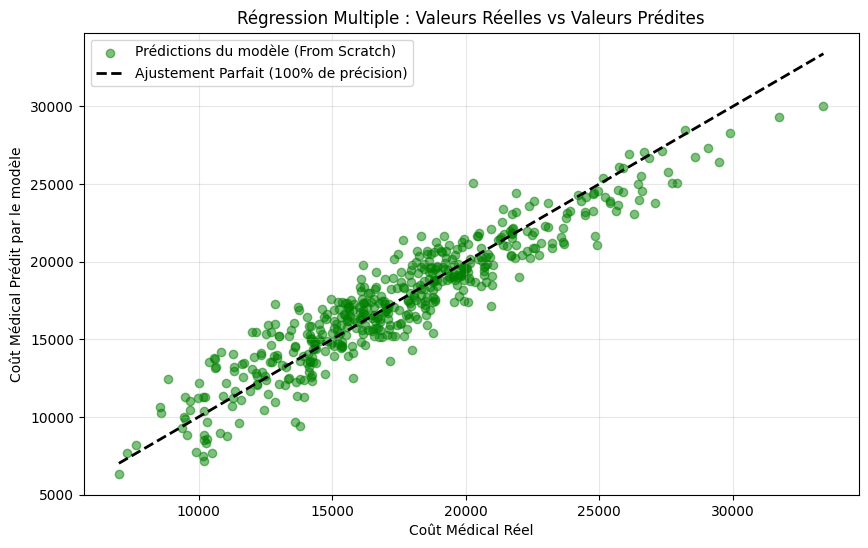

In [ ]:
# ==========================================
# Objectif : Prédire le coût avec plusieurs variables (Âge, BMI, Enfants)
# ==========================================

# 1. Entraînement des deux modèles avec la matrice à 3 dimensions (X_multi)
model_multi = RegressionFromScratch()
model_multi.fit(X_multi, y)

sk_multi = LinearRegression().fit(X_multi, y)

# 2. Génération des prédictions
y_pred_scratch = model_multi.predict(X_multi)

# 3. Visualisation (Impossible de tracer en 4D, on trace donc Réel vs Prédit)
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred_scratch, color='green', alpha=0.5, label='Prédictions du modèle (From Scratch)')

# Tracer une ligne diagonale représentant la perfection (Prédiction = Réalité)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='black', linestyle='dashed', lw=2, label='Ajustement Parfait (100% de précision)')

plt.title('Régression Multiple : Valeurs Réelles vs Valeurs Prédites')
plt.xlabel('Coût Médical Réel')
plt.ylabel('Coût Médical Prédit par le modèle')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### TEST 3 : RÉGRESSION POLYNOMIALE

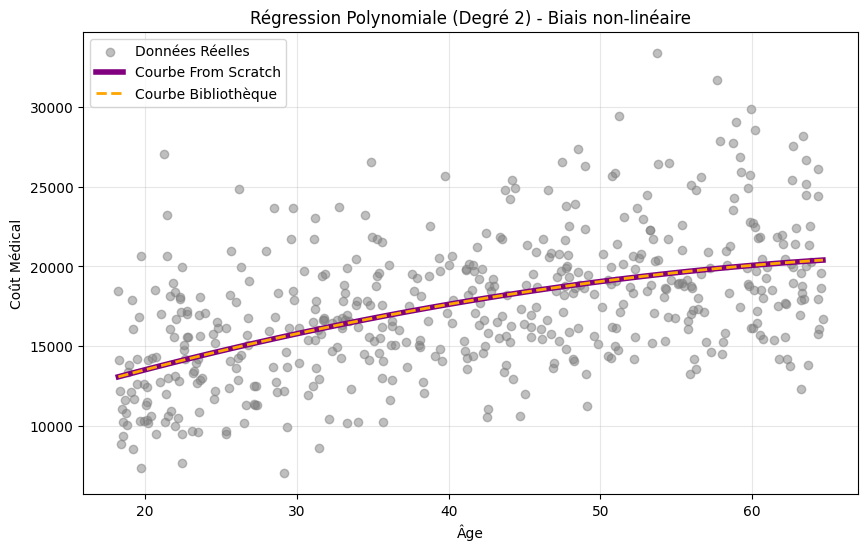

In [ ]:
# ==========================================
# Objectif : Permettre à la droite de se courber en ajoutant des variables au carré
# ==========================================

# 1. Préparation manuelle des données (Ajout de la colonne Age^2)
X_poly_scratch = np.c_[X_simple, X_simple**2]
model_poly = RegressionFromScratch()
model_poly.fit(X_poly_scratch, y)

# 2. Préparation via la bibliothèque Scikit-Learn (PolynomialFeatures)
poly_feats = PolynomialFeatures(degree=2, include_bias=False)
X_poly_sk = poly_feats.fit_transform(X_simple)
sk_poly = LinearRegression().fit(X_poly_sk, y)

# 3. Création des lignes de tracé courbées
X_plot_poly = np.c_[X_plot, X_plot**2]
X_plot_poly_sk = poly_feats.transform(X_plot)

# 4. Visualisation
plt.figure(figsize=(10, 6))
plt.scatter(X_simple, y, color='gray', alpha=0.5, label='Données Réelles')

# Affichage de notre courbe mathématique
plt.plot(X_plot, model_poly.predict(X_plot_poly), color='purple', linewidth=4, label='Courbe From Scratch')
# Affichage de la courbe Scikit-Learn
plt.plot(X_plot, sk_poly.predict(X_plot_poly_sk), color='orange', linestyle='dashed', linewidth=2, label='Courbe Bibliothèque')

plt.title('Régression Polynomiale (Degré 2) - Biais non-linéaire')
plt.xlabel('Âge')
plt.ylabel('Coût Médical')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()